# 01 — Exploración Inicial del Dataset
**Proyecto:** Sistema de Clasificación de Riesgo Académico Estudiantil  
**Dataset:** Students Performance Dataset — Rabie El Kharoua (Kaggle, 2024)  
**Estudiante:** Jesus Gabriel Maiguel Yerena  
**Programa:** Tecnología en Desarrollo de Software  
**Fecha:** Junio 16 de 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('Blues_d')
pd.set_option('display.max_columns', None)
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga del dataset

In [2]:
df = pd.read_csv('../data/raw/students_performance.csv')
print('Dataset cargado exitosamente')
print(f'Dimensiones: {df.shape}')

Dataset cargado exitosamente
Dimensiones: (2392, 15)


## 2. Tipos de variables

In [3]:
print(df.dtypes)

StudentID                str
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass             int64


## 3. Primeras filas

In [4]:
df.head()

  StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering   GPA  GradeClass
0  EST-0001   17       1          1                  2             19.9         7         1                2                0       1      1             0  4.00           0
1  EST-0002   18       0          0                  2             15.9         0         0                2                0       1      0             0  3.03           1
2  EST-0003   15       0          2                  4              5.8        14         0                3                1       1      1             1  1.69           4
3  EST-0004   17       1          0                  4             11.0        17         0                3                1       0      0             1  2.27           3
4  EST-0005   17       1          0                  2              6.2         0         1                3                1       1  

## 4. Estadísticas descriptivas

In [5]:
df.describe().round(2)

           Age   Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  Tutoring  ParentalSupport  Extracurricular   Sports    Music  Volunteering      GPA  GradeClass
count  2392.00  2392.00    2392.00            2392.00          2392.00   2392.00   2392.00          2392.00           2392.0  2392.00  2392.00       2392.00  2392.00     2392.00
mean     16.47     0.51       0.97               2.39            10.80     12.20      0.49             2.34              0.5     0.52     0.51          0.49     2.91        1.71
std       1.12     0.50       0.99               1.15             5.09      7.14      0.50             1.07              0.5     0.50     0.50          0.50     0.66        1.26
min      15.00     0.00       0.00               0.00             2.00      0.00      0.00             0.00              0.0     0.00     0.00          0.00     0.81        0.00
25%      15.00     0.00       0.00               1.00             6.50      6.00      0.00             2.00   

## 5. Calidad de los datos — Nulos y duplicados

In [6]:
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal de nulos: {nulos.sum()}')
print(f'Registros duplicados: {df.duplicated().sum()}')

Valores nulos por columna:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0

Total de nulos: 0
Registros duplicados: 0


## 6. Distribución de la variable objetivo

In [7]:
dist = df['GradeClass'].value_counts().sort_index()
labels = {0:'A (Excelente)',1:'B (Bueno)',2:'C (Promedio)',3:'D (Bajo)',4:'F (Reprobado)'}
for k,v in dist.items():
    print(f'  Clase {k} ({labels[k]}): {v} ({v/len(df)*100:.1f}%)')

Distribución de GradeClass:
  Clase 0 (A): 518 (21.7%)
  Clase 1 (B): 559 (23.4%)
  Clase 2 (C): 644 (26.9%)
  Clase 3 (D): 447 (18.7%)
  Clase 4 (F): 224 (9.4%)


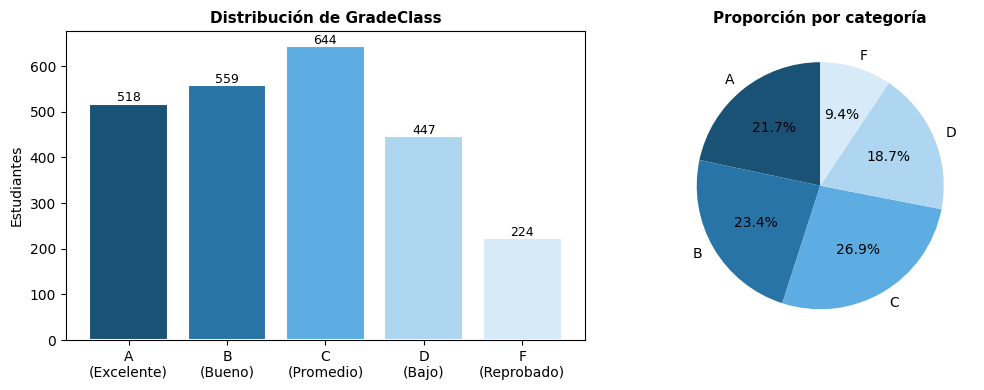

In [8]:
# Visualización distribución
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = ['#1A5276','#2874A6','#5DADE2','#AED6F1','#D6EAF8']
valores = [df['GradeClass'].value_counts().sort_index()[i] for i in range(5)]
etiq = ['A\n(Excelente)','B\n(Bueno)','C\n(Promedio)','D\n(Bajo)','F\n(Reprobado)']
axes[0].bar(etiq, valores, color=colores, edgecolor='white')
axes[0].set_title('Distribución de GradeClass', fontweight='bold')
axes[1].pie(valores, labels=['A','B','C','D','F'], colors=colores, autopct='%1.1f%%')
axes[1].set_title('Proporción', fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Correlación con la variable objetivo

In [9]:
vars_num = ['StudyTimeWeekly','Absences','GPA','Tutoring','ParentalSupport']
for v in vars_num:
    print(f'  {v}: {df[v].corr(df["GradeClass"]):.3f}')

Correlación con GradeClass (0=A ... 4=F):
  StudyTimeWeekly: -0.490
  Absences: 0.493
  GPA: -0.969
  Tutoring: -0.284
  ParentalSupport: -0.185


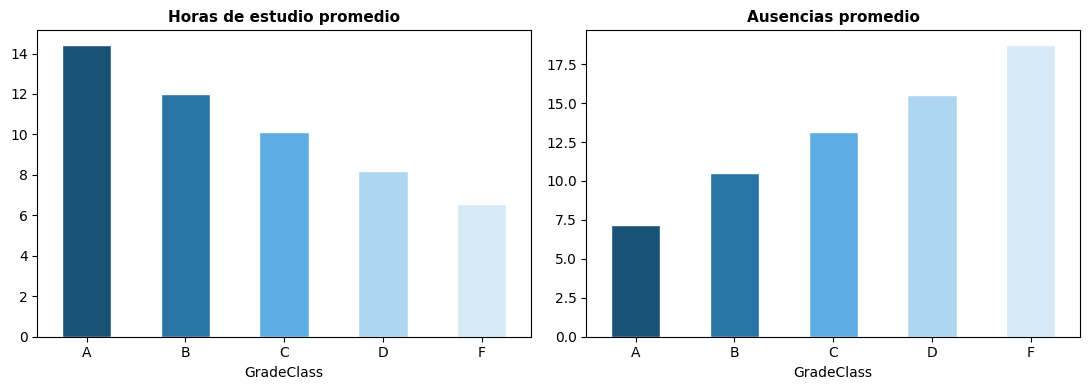

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.groupby('GradeClass')['StudyTimeWeekly'].mean().plot(kind='bar', ax=axes[0], color=colores)
axes[0].set_title('Horas de estudio promedio', fontweight='bold')
axes[0].set_xticklabels(['A','B','C','D','F'], rotation=0)
df.groupby('GradeClass')['Absences'].mean().plot(kind='bar', ax=axes[1], color=colores)
axes[1].set_title('Ausencias promedio', fontweight='bold')
axes[1].set_xticklabels(['A','B','C','D','F'], rotation=0)
plt.tight_layout(); plt.show()

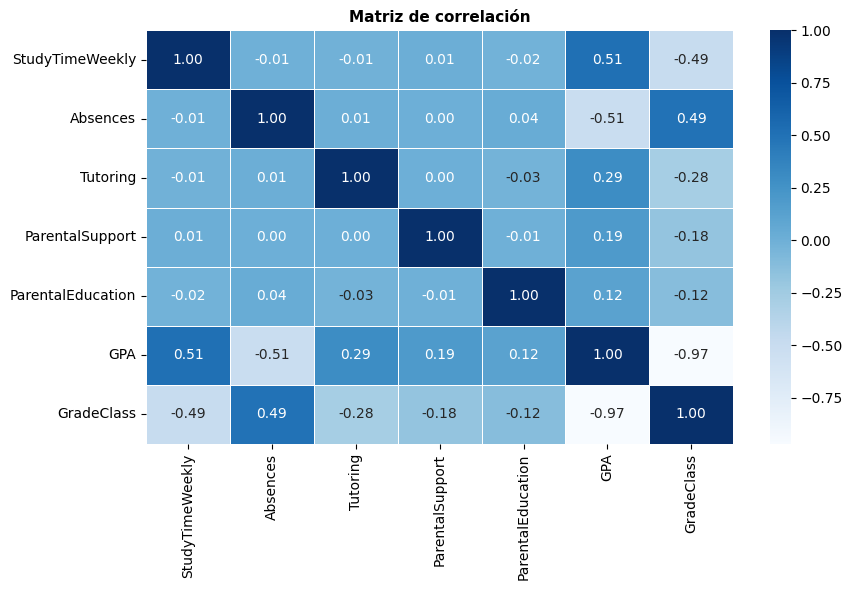

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
nc = ['StudyTimeWeekly','Absences','Tutoring','ParentalSupport','ParentalEducation','GPA','GradeClass']
sns.heatmap(df[nc].corr(), annot=True, fmt='.2f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlación', fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Conclusiones de la exploración

- **2.392 registros, 15 columnas**, sin valores nulos ni duplicados — dataset de alta calidad.
- **Desbalance moderado** en GradeClass: C es la clase más frecuente (26.9%), F la menos (9.4%). Justifica el uso de F1-score macro.
- `StudyTimeWeekly` correlaciona negativamente con GradeClass: más horas de estudio → mejor nota.
- `Absences` correlaciona positivamente: más ausencias → peor rendimiento (categoría más alta = F).
- `GPA` es el predictor más fuerte; debe evaluarse data leakage antes de incluirlo en el modelo.
- El dataset es **pertinente** para responder la pregunta analítica formulada.